### Import libraries

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

### Load Dataset

In [7]:
df = pd.read_csv('data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
print(df.shape)
print(df.info())

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

- Shape (891, 12)
- Null values on Age, Cabin, Embarked
- No duplicates
- Cat Cols: Name, Sex, Ticket, Cabin, Embarked
- Numerical Cols: PassengerId, Pclass, Age, SibSp, Parch, Fare
- Target Col: Survived

### EDA

In [14]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [19]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [17]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

- Around ~38% only survived
- Based on gender only ~18% male and around ~74% females survived
- Based on Pclass survival rate was ~62% on 1, ~47% on 2, ~24% on 3.

#### Plots

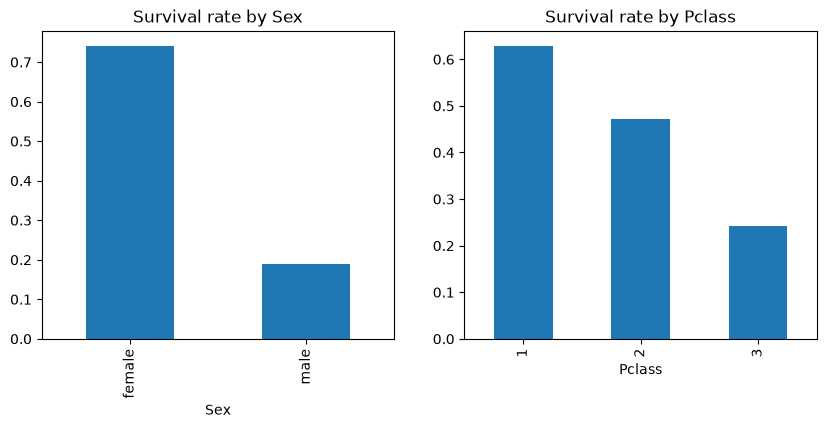

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', title='Survival rate by Sex', ax=axes[0]
)

df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', title='Survival rate by Pclass', ax=axes[1]
)

plt.show()

<Axes: xlabel='Age'>

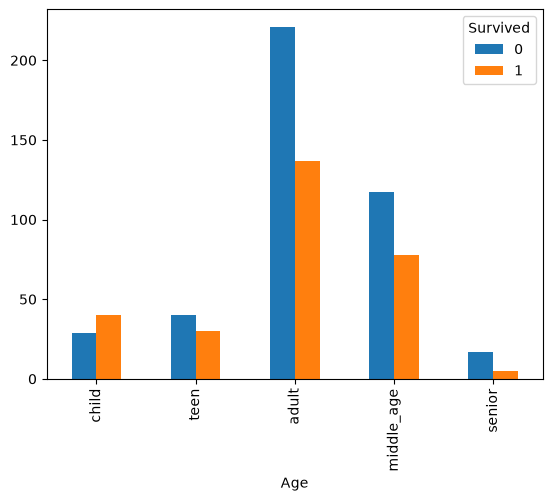

In [41]:
age_groups = pd.cut(df['Age'], bins=[0,12,18,35,60,100], 
    labels=['child', 'teen', 'adult', 'middle_age', 'senior']
)

df.groupby(age_groups, observed=True)['Survived'].value_counts().unstack().plot(kind='bar')

- the survival rate of child is greater in comparision
- the survival rate of senior is very low

In [ ]:
df.corr(numeric_only=True)['Survived'].drop('Survived').sort_values(ascending=False)

Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

Fare has a decent correlation where as Pclass has the most negative correlation

### Conclusion

It's mentioned that at the time of this incident, children and womens were given the priority and evacuated first and from the EDA we we performed it also aligns. The survival rate of women is around ~70% and from the age group the highest survival rate was also child. We also saw that people who were in higher class had higher survival rate.